## Final Project Notebook

In [27]:
# Import Necessary libraries
import nltk
from nltk.corpus import brown
import pickle
import json
import numpy as np

# Load both the lemmetizer, the cmu dictionary, and the cmu to ipa conversion table
lemma_dict = pickle.load(open("ant_lemmas.pickle","rb"))
cmu = nltk.corpus.cmudict.dict()
with open("cmu_to_ipa.json", "r") as file:
    cmu_to_ipa = json.load(file)

# Make cmu pronuncations into strings of ipa
cmu_strings = dict()
for word in cmu:
    string_prons = []
    for pron in cmu[word]:
        try:
            string_prons.append(''.join([cmu_to_ipa.get(char) for char in pron]))
        except:
            pass
    cmu_strings[word] = string_prons

# Assemble all the words in the Brown corpus into a dict with the word, pos tag, and frequency
brown_dict = dict()
for pair in brown.tagged_words():
    try:
        brown_dict[pair[0].lower()][2]+=1
        brown_dict[pair[0].lower()][1].add(pair[1])
    except:
        brown_dict[pair[0].lower()] = [pair[0].lower(),{pair[1]},1]

# Seperate out all the words which were tagged as VB or VBD
present_verbs = []
past_verbs = []
for value in brown_dict.values():
    if 'VB' in value[1]:
        present_verbs.append(value[0])
    elif 'VBD' in value[1]:
        past_verbs.append(value[0])

# Lemmatize each verb in the infinitive
lemma_present = []
for verb in present_verbs:
    try:
        lemma_present.append((verb, lemma_dict[verb]))
    except:
        pass

# Lemmatize each verb in the past
lemma_past = []
for verb in past_verbs:
    try:
        lemma_past.append((verb, lemma_dict[verb]))
    except:
        pass

# Match up lemmatized versions of verbs to get our pairs
verb_pairs = []
for verb1 in lemma_present:
    for verb2 in lemma_past:
        if verb1[1]==verb2[1]:
            if cmu_strings.get(verb1[0])==None or cmu_strings.get(verb2[0])==None:
                pass
            else:
                verb_pairs.append((
                    (verb1[0],cmu_strings.get(verb1[0])[0]),
                    (verb2[0],cmu_strings.get(verb2[0])[0])
                ))
            break

# First 10 elements
print(verb_pairs[:10])

[(('place', 'pleɪs'), ('placed', 'pleɪst')), (('charge', 'ʧɑrʤ'), ('charged', 'ʧɑrʤd')), (('praise', 'preɪz'), ('praised', 'preɪzd')), (('term', 'tɝm'), ('termed', 'tɝmd')), (('judge', 'ʤʌʤ'), ('judged', 'ʤʌʤd')), (('investigate', 'ɪnvɛstəgeɪt'), ('investigated', 'ɪnvɛstəgeɪtəd')), (('interest', 'ɪntrəst'), ('interested', 'ɪntrəstəd')), (('number', 'nʌmbɚ'), ('numbered', 'nʌmbɚd')), (('size', 'saɪz'), ('sized', 'saɪzd')), (('act', 'ækt'), ('acted', 'æktəd'))]


### Fasttext

In [2]:
from gensim.models.fasttext import FastText
from gensim.test.utils import common_texts

In [3]:
pronounce_present = [list(verb[0][1]) for verb in verb_pairs]

In [4]:
model = FastText(vector_size=100, window=5, min_count=1, min_n=2, max_n=4)
model.build_vocab(corpus_iterable=pronounce_present)
model.train(corpus_iterable=pronounce_present, total_examples=len(pronounce_present), epochs=10)

(17270, 80000)

In [5]:
vec2 = model.wv["pleɪs"]
vec3 = model.wv['ɪnvɛstəgeɪt']

In [6]:
vec1= model.wv.get_vector("pleɪst")

In [5]:
import numpy as np

print(np.dot(vec1,vec2))
print(np.dot(vec1,vec3))

NameError: name 'vec1' is not defined

### GenSim Pretrained

In [2]:
import gensim
from gensim import downloader

In [3]:
glove_vectors50 = gensim.downloader.load('glove-wiki-gigaword-50')

In [6]:
x_list = list()
y_list = list()
for verb in verb_pairs:
    try:
        y_list.append(glove_vectors50.get_vector(verb[1][0]))
        x_list.append(glove_vectors50.get_vector(verb[0][0]))
    except:
        pass
X = np.array(x_list)
y = np.array(y_list)

In [27]:
# See if it can predict a shift to the past tense
def word_in_top_n(y_pred,y_test,n=10):
    right = 0
    wrong = 0
    for vec in enumerate(y_pred):
        answer = glove_vectors50.similar_by_vector(y_test[vec[0]], topn=1)[0][0]
        if answer in [ele[0] for ele in glove_vectors50.similar_by_vector(vec[1], topn=n)]:
            right+=1
        else:
            wrong+=1
    
    return right/(right+wrong)

In [62]:
dot_scores

[]

In [63]:
%%time
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dot_scores = []
top_n_scores = []
for layer in range(1,5):
    layer_scores_dot = []
    layer_scores_top_n = []
    for nodes in range(10,100,10):
        hidden_layer_tuple = tuple([nodes]*layer)
        regr = MLPRegressor(hidden_layer_sizes=hidden_layer_tuple,random_state=1, max_iter=2000, tol=0.1)
        regr.fit(X_train, y_train)
        y_pred = regr.predict(X_test)
        layer_scores_dot.append(np.mean([np.dot(y_pred[i],y_test[i]) for i in range(len(X_test))]))
        layer_scores_top_n.append(word_in_top_n(y_pred,y_test))
    dot_scores.append(layer_scores_dot)
    top_n_scores.append(layer_scores_top_n)

CPU times: user 30min 3s, sys: 1min 8s, total: 31min 12s
Wall time: 4min 14s


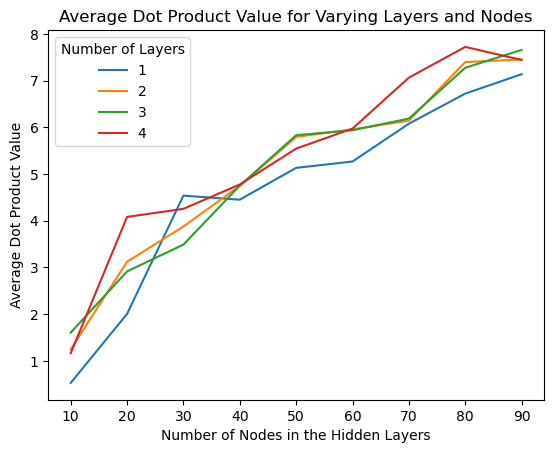

In [76]:
import matplotlib.pyplot as plt 
for layer in enumerate(dot_scores):
    plt.plot(range(10,100,10),layer[1],label=layer[0]+1)

plt.legend(title='Number of Layers')
plt.title("Average Dot Product Value for Varying Layers and Nodes")
plt.xlabel("Number of Nodes in the Hidden Layers")
plt.ylabel("Average Dot Product Value")
plt.show()
# plt.savefig('dotproduct.png')

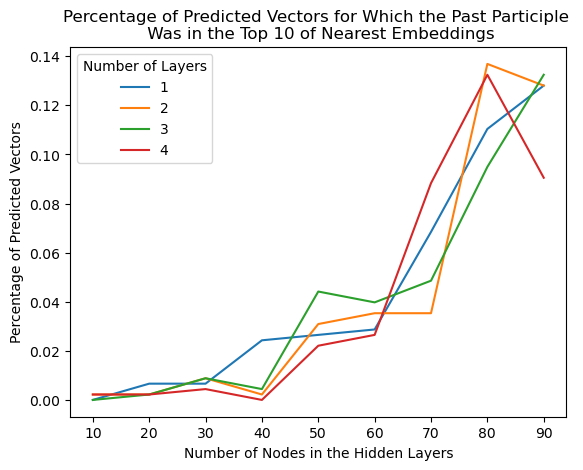

In [79]:
for layer in enumerate(top_n_scores):
    plt.plot(range(10,100,10),layer[1],label=layer[0]+1)

plt.legend(title='Number of Layers')
plt.title("Percentage of Predicted Vectors for Which the Past Participle \n Was in the Top 10 of Nearest Embeddings")
plt.xlabel("Number of Nodes in the Hidden Layers")
plt.ylabel("Percentage of Predicted Vectors")
plt.show()
# plt.savefig('percentage.png')

### Simple N-gramming

In [16]:
def n_gram(word,n=3):
    grams = [word[i:i+n] for i in range(len(word)-n+1)]
    return grams

In [17]:
n_grams = set()
for pair in verb_pairs:
    n_grams.update(n_gram(pair[0][1]))
    n_grams.update(n_gram(pair[1][1]))

n_grams_key = list(n_grams)

In [18]:
def make_ngram_vec(word,vec_key,n=3):
    vec = [0]*len(n_grams_key)
    for gram in n_gram(word,n):
        vec[n_grams_key.index(gram)]+=1
    return vec

In [19]:
x_list = list()
y_list = list()
for verb in verb_pairs:
    try:
        y_list.append(make_ngram_vec(verb[1][1],n_grams_key))
        x_list.append(make_ngram_vec(verb[0][1],n_grams_key))
    except:
        pass
X = np.array(x_list)
y = np.array(y_list)

In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

regr = MLPRegressor(random_state=1, max_iter=2000, tol=0.1)
regr.fit(X_train, y_train)


MLPRegressor(max_iter=2000, random_state=1, tol=0.1)

In [21]:
y_pred = regr.predict(X_test)

### Wickelfeature Recreation

In [25]:
from mappings import wickelphones_dict, reference_chart, new_reference_chart

# Transforms the cmu dictionary into ipa again but leaves phonemes seperate instead of combining
cmu_pronuciation = dict()
for word in cmu:
    string_prons = []
    for pron in cmu[word]:
        try:
            string_prons.append([cmu_to_ipa.get(char) for char in pron])
        except:
            pass
    cmu_pronuciation[word] = string_prons

# Create a match up of verb pairs and their pronuciations
wickel_verb_pairs = []
for verb1 in lemma_present:
    for verb2 in lemma_past:
        if verb1[1]==verb2[1]:
            if cmu_pronuciation.get(verb1[0])==None or cmu_pronuciation.get(verb2[0])==None:
                pass
            else:
                wickel_verb_pairs.append((
                    (verb1[0],cmu_pronuciation.get(verb1[0])[0]),
                    (verb2[0],cmu_pronuciation.get(verb2[0])[0])
                ))
            break

# Because 'owe' is just a dipthong, it has word boundaries on either side. This created a number of problems.
# Don't ask me how long it took to figure out my issues came down to this word. I don't want to talk about it lol
wickel_verb_pairs.remove((('owe', ['oʊ']), ('owed', ['oʊ', 'd'])))

def wickelphones(word): # Create all three-character wickelphone for a word
    bounded_word = ['#']+word+['#']
    phones = [bounded_word[i:i+3] for i in range(len(bounded_word)-2)]
    return phones

def wickel_encode(triple): # Turn a single wickelphone into its numeric representation
    return [wickelphones_dict.get(triple[0]),wickelphones_dict.get(triple[1]),wickelphones_dict.get(triple[2])]

def mask(vec, pos): # Helper function to create unique indicies for a wickelfeature
    string = ''
    for loc, tup in enumerate(vec):
        if pos==loc:
            string+=''.join([str(val) for val in tup])
        else:
            string+=len(tup)*'x'
    return string

def get_wickelfeatures(wickelphone): # Take in a wickelphone and give out all unique wickelfeature representations
    indices = []
    if wickelphone[0][4]==(1,):
        for i in range(4):
            for j in range(4):
                string_index = 'x'*11+mask(wickelphone[1],i)+mask(wickelphone[2],j)
                indices.append(string_index)
    elif wickelphone[2][4]==(1,):
        for i in range(4):
            for j in range(4):
                string_index = mask(wickelphone[0],i)+mask(wickelphone[1],j)+'x'*11
                indices.append(string_index)
    else:
        for i in range(4):
            for j in range(4):
                string_index = mask(wickelphone[0],j)+mask(wickelphone[1],i)+mask(wickelphone[2],j)
                indices.append(string_index)
    return indices

def get_wickel_vector(verb): # Turns a word into the vector representation with 457 dimensions
    pron = cmu_pronuciation[verb][0]
    wickelphons = wickelphones(pron)
    wickel_indices = set()
    for phon in wickelphons:
        string_indices = get_wickelfeatures(wickel_encode(phon))
        for string in string_indices:
            wickel_indices.add(reference_chart.get(string))
    wickel_vector = [0]*457
    for i in wickel_indices:
        wickel_vector[i]=1
    return wickel_vector

def full_wickelfeatures(wickelphone):
    indices = []
    alpha = 'abcde'
    if wickelphone[0][4]==(1,):
        for i in range(4):
            for j in range(4):
                string_index = 'e0'+alpha[i]+str(wickelphone[1][i].index(1))+alpha[j]+str(wickelphone[2][j].index(1))
                indices.append(string_index)
    elif wickelphone[2][4]==(1,):
        for i in range(4):
            for j in range(4):
                string_index = alpha[i]+str(wickelphone[0][i].index(1))+alpha[j]+str(wickelphone[1][j].index(1))+'e0'
                indices.append(string_index)
    else:
        for i in range(4):
            for j in range(4):
                for k in range(4):
                    string = alpha[i]+str(wickelphone[0][i].index(1))+alpha[j]+str(wickelphone[1][j].index(1))+alpha[k]+str(wickelphone[2][k].index(1))
                    indices.append(string)
    return indices

def get_full_wickel_vector(verb): # Turns a word into the vector representation with 1210 dimensions
    pron = cmu_pronuciation[verb][0]
    wickelphons = wickelphones(pron)
    wickel_indices = set()
    for phon in wickelphons:
        string_indices = full_wickelfeatures(wickel_encode(phon))
        for string in string_indices:
            wickel_indices.add(new_reference_chart.get(string))
    wickel_vector = [0]*1210
    for i in wickel_indices:
        wickel_vector[i]=1
    return wickel_vector

In [28]:
x_list = list()
y_list = list()

for verb in wickel_verb_pairs:
    x_list.append(get_full_wickel_vector(verb[0][0]))
    y_list.append(get_full_wickel_vector(verb[1][0]))

wickel_X = np.array(x_list)
wickel_y = np.array(y_list)

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

wickel_X_train, wickel_X_test, wickel_y_train, wickel_y_test = train_test_split(wickel_X, wickel_y, test_size=0.3, random_state=42)

regr = MLPClassifier(hidden_layer_sizes=(1000,),random_state=1, max_iter=2000, tol=0.1)
regr.fit(wickel_X_train, wickel_y_train)
print(regr.score(wickel_X_test,wickel_y_test))

0.07947019867549669
